In [97]:
import os
import mne
import numpy as np
import pandas as pd
import pyecap
from flexNIRs.fnirs_functions import *

import matplotlib.pyplot as plt
import h5py
import mne
import mne.channels
import mne.io.snirf
import mne_nirs.experimental_design
import mne_nirs.statistics

from nilearn.plotting import plot_design_matrix

import mne_nirs
from mne_nirs.channels import get_long_channels, get_short_channels, picks_pair_to_idx
from mne_nirs.experimental_design import make_first_level_design_matrix
from mne_nirs.statistics import run_glm

def get_snirf_file(data_path, hash, snirf_type):
    fileLIST = os.listdir(data_path + r'\\SNIRF')
    snirf_file = [item for item in fileLIST if (hash.lower() in item.lower()) and (snirf_type.lower() in item.lower())][0]
    full_path = data_path + r'\\SNIRF\\' + snirf_file
    return full_path

In [57]:
meta_index = 5
snirf_type = 'gates'  #Either 'gates' or 'moments'

path = r'D:\Data\Kernel\20260312_Kernel_QC\\'
path = r'D:\Data\Kernel\20260327_Kernel_QC\study-uwqctesting_sub-kc_desc-cd3350b_MOMENTS.snirf'

#metaDF = pd.read_excel(path + 'metadata.xlsx')
#tank = path + r'\\Tanks\\' + metaDF.at[meta_index, 'Tank']
#snirf = get_snirf_file(path, metaDF.at[meta_index, 'Kernel Hash'], snirf_type)

#stim = pyecap.Stim(tank)
#stimDF = stim.parameters
#stimDF
#fnirsDF = flex_import(flex_folder)

In [58]:
#print(snirf)
snirf = path
raw = mne.io.snirf.read_raw_snirf(snirf)
raw.load_data()
#raw.annotations.to_data_frame()

Loading D:\Data\Kernel\20260327_Kernel_QC\study-uwqctesting_sub-kc_desc-cd3350b_MOMENTS.snirf
Found jitter of 0.000062% in sample times.
Reading 0 ... 1590  =      0.000 ...   422.939 secs...


<RawSNIRF | study-uwqctesting_sub-kc_desc-cd3350b_MOMENTS.snirf, 300 x 1591 (423.2 s), ~3.9 MiB, data loaded>

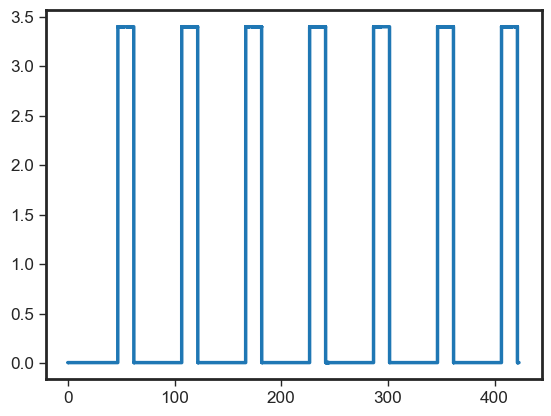

In [105]:
"""Get Sync Signal"""
f = h5py.File(path)
sync_signal = f['nirs']['aux22']['dataTimeSeries'][:]
sync_time = f['nirs']['aux22']['time'][:]
plt.plot(sync_time, sync_signal)

In [104]:
sync_signal[:]

array([[0.00553461],
       [0.00537648],
       [0.00553461],
       ...,
       [0.00553461],
       [0.00553461],
       [0.00553461]], shape=(147210, 1), dtype=float32)

In [73]:
x = f['nirs']['aux22']['dataTimeSeries']
t = f['nirs']['aux22']['time']

In [87]:
aux = f['nirs']['aux22']

In [93]:
aux.keys()

<KeysViewHDF5 ['dataTimeSeries', 'name', 'time']>

In [94]:
aux.name

'/nirs/aux22'

In [96]:
aux['time']

<HDF5 dataset "time": shape (147210,), type "<f8">

53.40987968444824
50.404852628707886


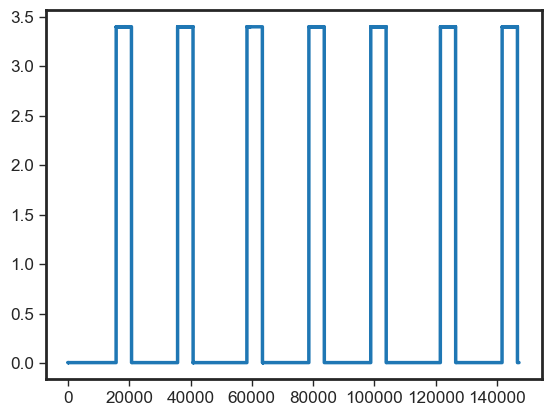

In [85]:
print(t[18000])
print(t[17000])
#t[17000] - t[17001]
rate = np.diff(t)
plt.plot(x)

Rate is 998.168491Hz


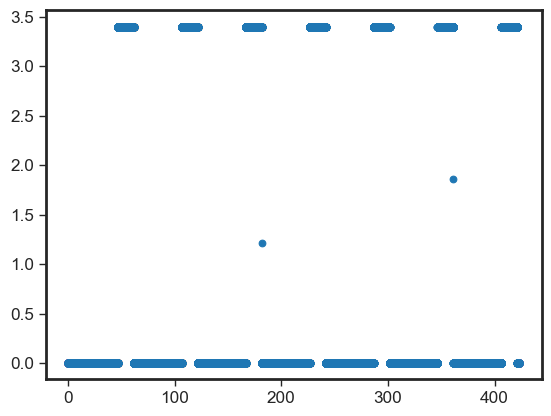

In [83]:
from matplotlib import pyplot as plt

found_aux = None
for k in f['nirs'].keys():
    if 'aux' in k:
        name = f['nirs'][k]['name'][()]
        if name == b'SyncboxI0Lowsampling':
            found_aux = k

if found_aux:
    times = f['nirs'][found_aux]['time']
    rate = 1 / np.median(np.diff(times))
    print(f"Rate is {rate:2f}Hz")

    plt.scatter(
        times,
        f['nirs'][found_aux]['dataTimeSeries']
    )

In [52]:
aux_df = mne_nirs.io.read_snirf_aux_data(path, raw)

IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

In [16]:
probe_keys = [
    ("detectorLabels", str),
    ("sourceLabels", str),
    ("sourcePos3D", float),
    ("detectorPos3D", float),
]
with h5py.File(snirf, "r") as file:
    probe_data = {
        key: np.array(file["nirs"]["probe"][key]).astype(dtype)
        for key, dtype in probe_keys
    }
[*probe_data]

['detectorLabels', 'sourceLabels', 'sourcePos3D', 'detectorPos3D']

In [17]:
"""Get the stim-relevant annotation from list of event types"""
with h5py.File(snirf, "r") as file:
  ctr = 1
  while (stim:=f"stim{ctr}") in file["nirs"]:
    print(stim, np.array(file["nirs"][stim]["name"]))
    ctr+=1

with h5py.File(snirf, "r") as file:
  df_start_block = pd.DataFrame(data = np.array(file["nirs"]["stim1"]["data"]), columns=[col.decode('UTF-8') for col in file["nirs"]["stim1"]["dataLabels"]])
df_start_block

KeyError: "Unable to synchronously open object (object 'stim1' doesn't exist)"

In [142]:
"""Write new annotations"""
events, _ = mne.events_from_annotations(raw, {"StartBreathHold": 1})
event_id = {"Stim": 2, "Breathing": 1}
#events[df_start_block["BlockType.Left"] == 1., 2] = event_id["Tapping/Left"]
#events[df_start_block["BlockType.Right"] == 1., 2] = event_id["Tapping/Right"]
events

Used Annotations descriptions: [np.str_('StartBreathHold')]


array([[1065,    0,    1],
       [1955,    0,    1],
       [2846,    0,    1],
       [3737,    0,    1],
       [4627,    0,    1],
       [5517,    0,    1],
       [6408,    0,    1]])

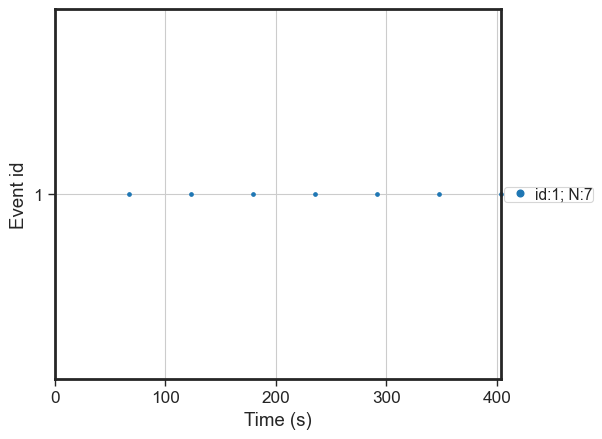

In [143]:
#event_id = {'StartBreathHold' : 2}
mne.viz.plot_events(events, sfreq=raw.info["sfreq"]);

In [145]:
tmin, tmax = -5, 30
epochs = mne.Epochs(
    raw,
    events,
    event_id=1,
    tmin=tmin,
    tmax=tmax,
    proj=True,
    baseline=(None, 0),
    preload=True,
    detrend=None,
    verbose=True,
)

Not setting metadata
7 matching events found
Setting baseline interval to [-4.977046014346716, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 7 events and 556 original time points ...
1 bad epochs dropped


In [146]:
idx_sources = np.array([int(ch.split("_")[0][1:]) - 1 for ch in epochs.info["ch_names"]])
idx_detectors = np.array([int(ch.split("_")[1].split(" ")[0][1:]) - 1 for ch in epochs.info["ch_names"]])
source_positions = np.array(probe_data["sourcePos3D"])[idx_sources]
detector_positions = np.array(probe_data["detectorPos3D"])[idx_detectors]
sds = np.sqrt(np.sum((source_positions - detector_positions) ** 2, axis=1))

In [130]:
"""Limits channels to include based on conditional"""
#idx_channels = np.flatnonzero((sds > 15) & (sds < 30))
idx_channels = np.flatnonzero((sds > 40))
stim_evoked = epochs.average(picks=idx_channels)

In [131]:
probe_data['sourceLabels']

array(['M000S00', 'M000S01', 'M000S02', 'M001S00', 'M001S01', 'M001S02',
       'M002S00', 'M002S01', 'M002S02'], dtype='<U7')

In [132]:
idx_sources = np.array([int(ch.split("_")[0][1:]) - 1 for ch in stim_evoked.info["ch_names"]]) #Generates array where value is the source # for each data stream
is_selected_hbo = np.array([ch.endswith("0") for ch in stim_evoked.info["ch_names"]]) #Generates boolean mask based on conditional to select which data streams to plot

# MODULE 0 is centered, MODULE 1 is left, MODULE 2 is right side -- Why do they limit to single source though?
left = is_selected_hbo & (idx_sources== np.flatnonzero(np.array(probe_data["sourceLabels"]) == "M001S01")[0])
center = is_selected_hbo & (idx_sources== np.flatnonzero(np.array(probe_data["sourceLabels"]) == "M000S01")[0])
right = is_selected_hbo & (idx_sources== np.flatnonzero(np.array(probe_data["sourceLabels"]) == "M002S01")[0])

# average all channels coming from source 20 or 21 formed with detectors between 15-30mm from the source
combined = mne.channels.combine_channels(stim_evoked, {"left": np.flatnonzero(left), "right": np.flatnonzero(right), 'center': np.flatnonzero(center)})

Applying baseline correction (mode: mean)


C:\Users\kpcheng\AppData\Local\Temp\ipykernel_34140\4240931156.py:2: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  mne.viz.plot_compare_evokeds(combined, picks = ['left'], legend='upper left', axes=ax, show=False)
C:\Users\kpcheng\AppData\Local\Temp\ipykernel_34140\4240931156.py:3: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  mne.viz.plot_compare_evokeds(combined, picks = ['right'], legend='upper left', axes=ax, show=False)
C:\Users\kpcheng\AppData\Local\Temp\ipykernel_34140\4240931156.py:4: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  mne.viz.plot_compare_evokeds(combined, picks = ['center'], legend='upper left', axes=ax, show=False)


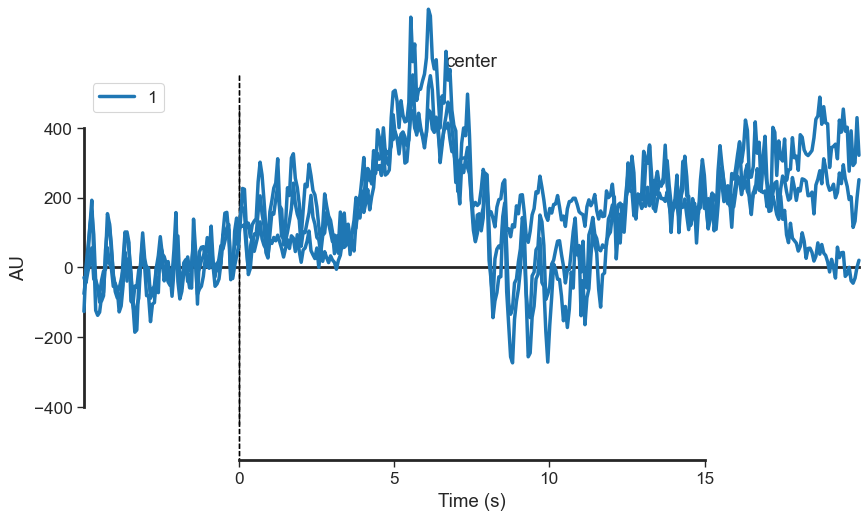

In [133]:
fig, ax = plt.subplots(figsize=(10, 5))
mne.viz.plot_compare_evokeds(combined, picks = ['left'], legend='upper left', axes=ax, show=False)
mne.viz.plot_compare_evokeds(combined, picks = ['right'], legend='upper left', axes=ax, show=False)
mne.viz.plot_compare_evokeds(combined, picks = ['center'], legend='upper left', axes=ax, show=False)
plt.show()

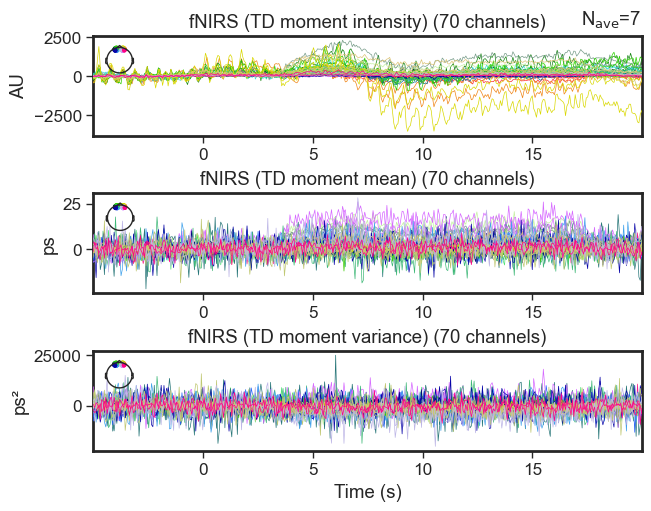

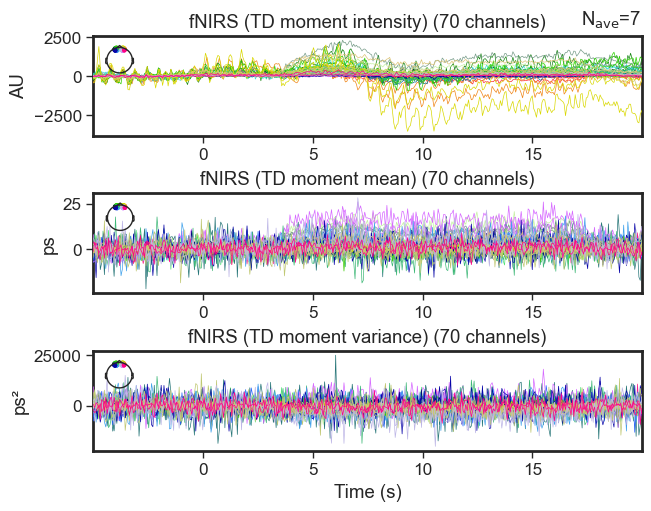

In [137]:
stim_evoked.plot()

In [18]:
channels = raw.ch_names

In [27]:
bins = [bin.split('bin')[1] for bin in channels]

In [29]:
bin_times = np.sort(np.array(list(set(bins))))